In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.append("../..")

from src.classifical_features import build_monthly_features
from src.configs.settings import Settings
from src.visualization.visualization import (
    plot_best_predictions,
    plot_overall_metrics_comparison,
    plot_panel_metrics_distributions,
    plot_worst_predictions,
)

settings = Settings()

In [2]:
data_dir = Path("../../data")

In [3]:
features_df = pd.read_csv(data_dir / "processed" / "mirrors_clusters.csv")
mirrors_ts_df = pd.read_csv(data_dir / "processed" / "filtered_mirrors_ts.csv")

In [4]:
features = build_monthly_features(mirrors_ts_df, settings)
features["panel_id"] = features[settings.columns.id].astype(str)

Processing panels:   0%|          | 0/1511 [00:00<?, ?it/s]

Processing panels: 100%|██████████| 1511/1511 [00:05<00:00, 297.02it/s]


In [5]:
is_core_mask = features_df.is_core.eq(True)

features_df[is_core_mask].cluster_final.value_counts()

cluster_final
4     463
1      71
7      55
3      55
11     51
8      38
5      33
10     33
2      29
6      27
9      16
0      15
12     15
Name: count, dtype: int64

In [6]:
cluster_mask = features_df.cluster_final.eq(8)

cluster_articles = features_df[cluster_mask].article.values

In [7]:
features = features[features.article.isin(cluster_articles)].reset_index(drop=True)

In [8]:
from src.catboost_utilities.evaluate import evaluate_catboost
from src.catboost_utilities.train import train_catboost
from src.custom_types import CatBoostParameters
from src.model_selection import temporal_panel_split_by_size

regression_splits = temporal_panel_split_by_size(
    features,
    panel_column='article',
    time_column='date',
    test_size=3,
    val_size=None
)

In [9]:
from src.data_processing import scale_panel_splits

scale = not settings.downstream.round_predictions
if scale:
    splits = scale_panel_splits(
        (data for _, data in regression_splits.splits),
        panel_column=settings.columns.id,
        target_columns=settings.columns.main_target,
        apply_log=settings.preprocessing.apply_log,
    )
else:
    splits = regression_splits

In [10]:
catboost_params = CatBoostParameters(
    iterations=500,
    learning_rate=0.05,
    depth=3,
    l2_leaf_reg=10,
    subsample=0.8,
    rsm=0.8,
    random_seed=settings.random_state,
    verbose=50,
    loss_function="RMSE",
)

catboost_model = train_catboost(
    train_df=splits.train,
    val_df=splits.val,
    params=catboost_params,
    settings=settings,
)

results = evaluate_catboost(
    model=catboost_model,
    splits=splits,
    settings=settings,
    scalers=None,
)

0:	learn: 7.6590233	total: 46.1ms	remaining: 23s
50:	learn: 4.2786685	total: 51ms	remaining: 449ms
100:	learn: 3.4549477	total: 54.2ms	remaining: 214ms
150:	learn: 3.0507321	total: 57.6ms	remaining: 133ms
200:	learn: 2.7961073	total: 61ms	remaining: 90.7ms
250:	learn: 2.6186180	total: 64ms	remaining: 63.5ms
300:	learn: 2.4312715	total: 67.6ms	remaining: 44.7ms
350:	learn: 2.2621210	total: 70.5ms	remaining: 29.9ms
400:	learn: 2.1271399	total: 74.1ms	remaining: 18.3ms
450:	learn: 2.0032398	total: 77.5ms	remaining: 8.42ms
499:	learn: 1.9235758	total: 80.8ms	remaining: 0us


Evaluating test panels: 100%|██████████| 48/48 [00:00<00:00, 1634.34it/s]


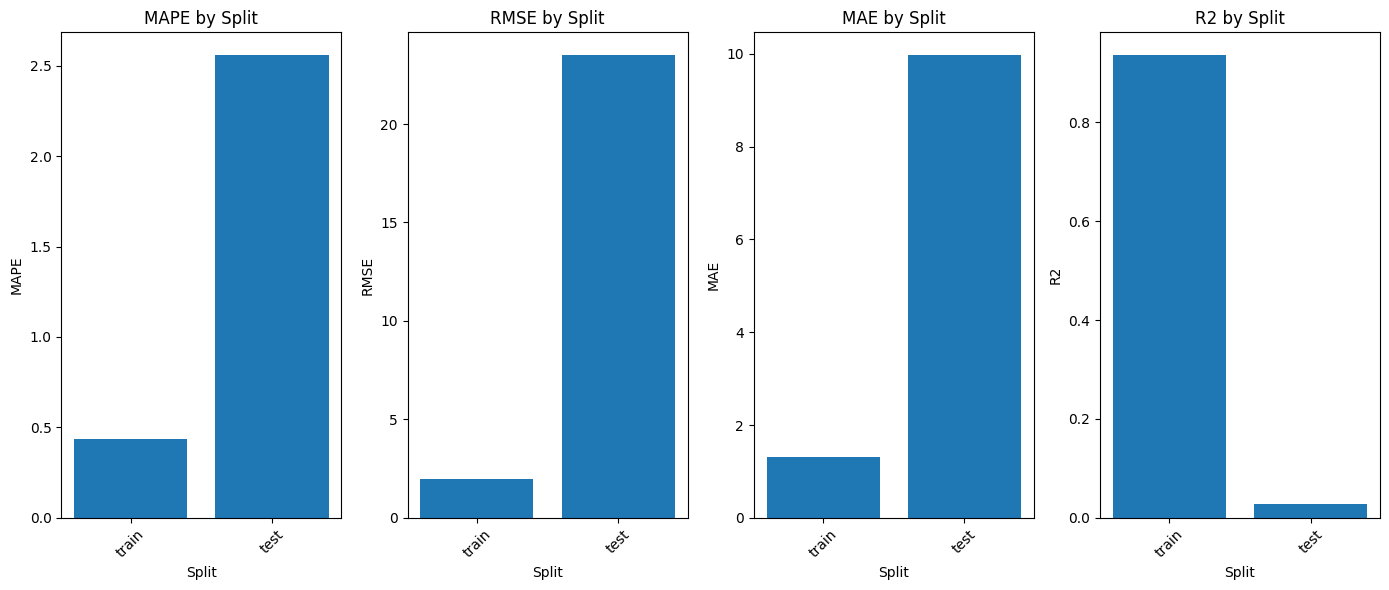

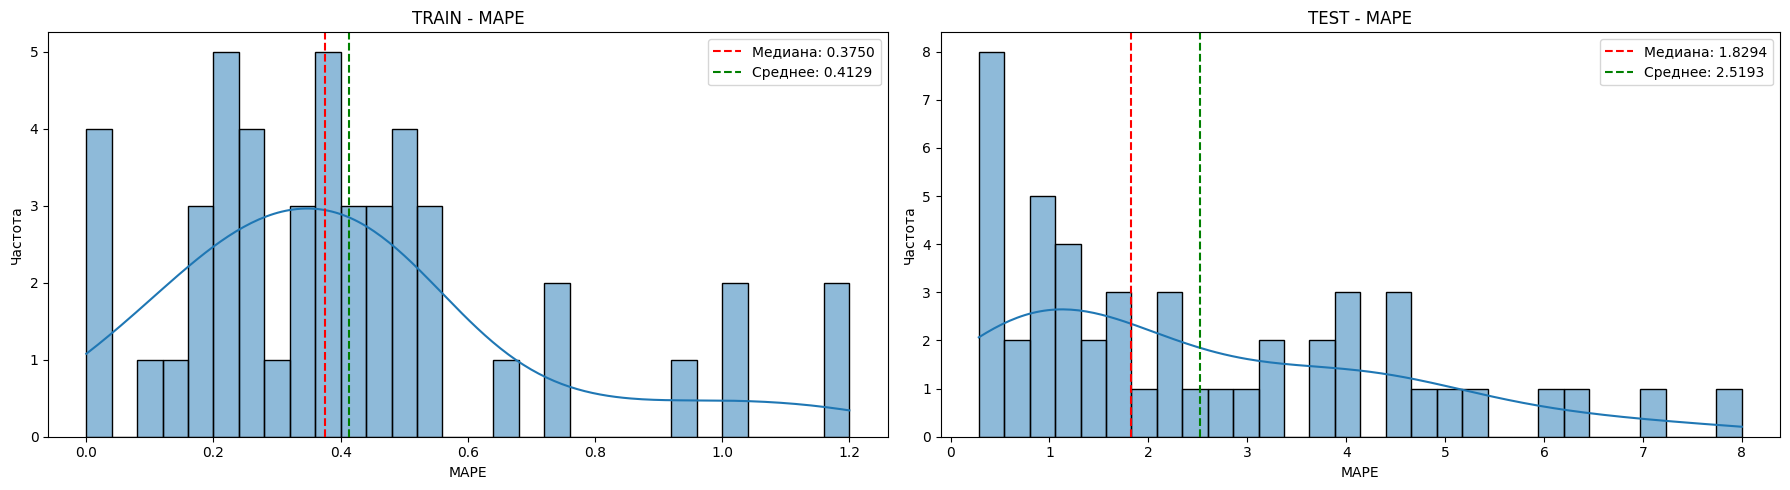

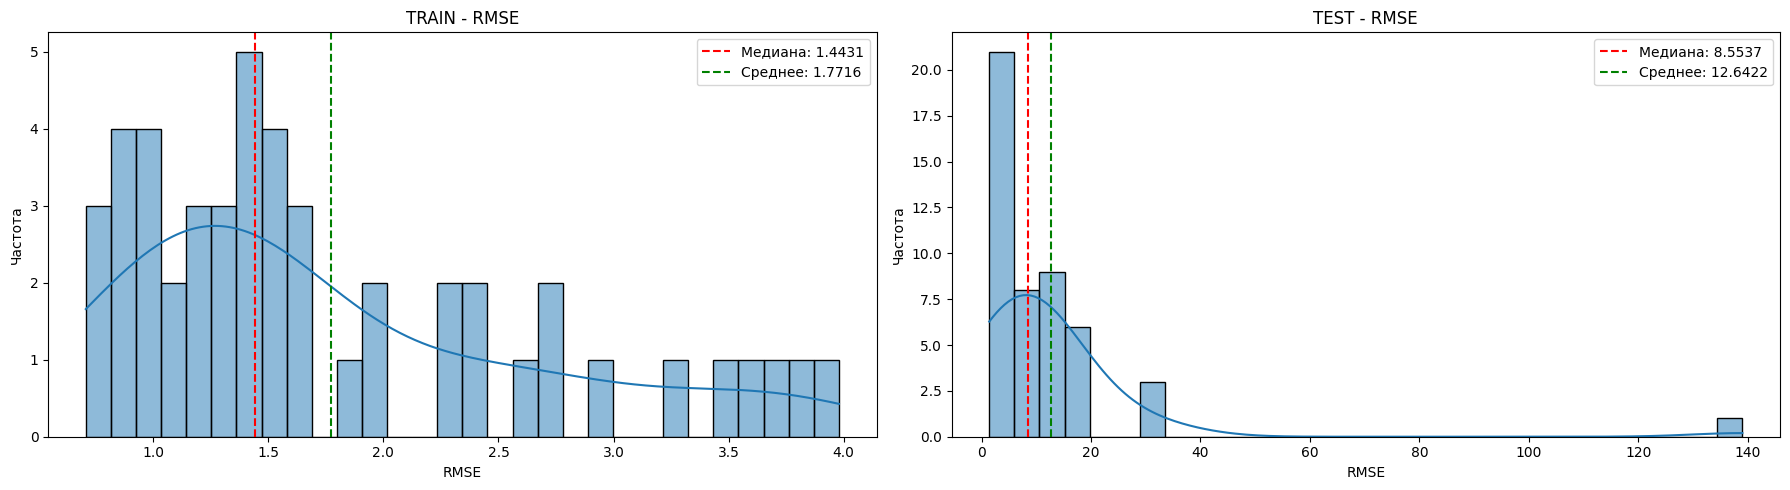

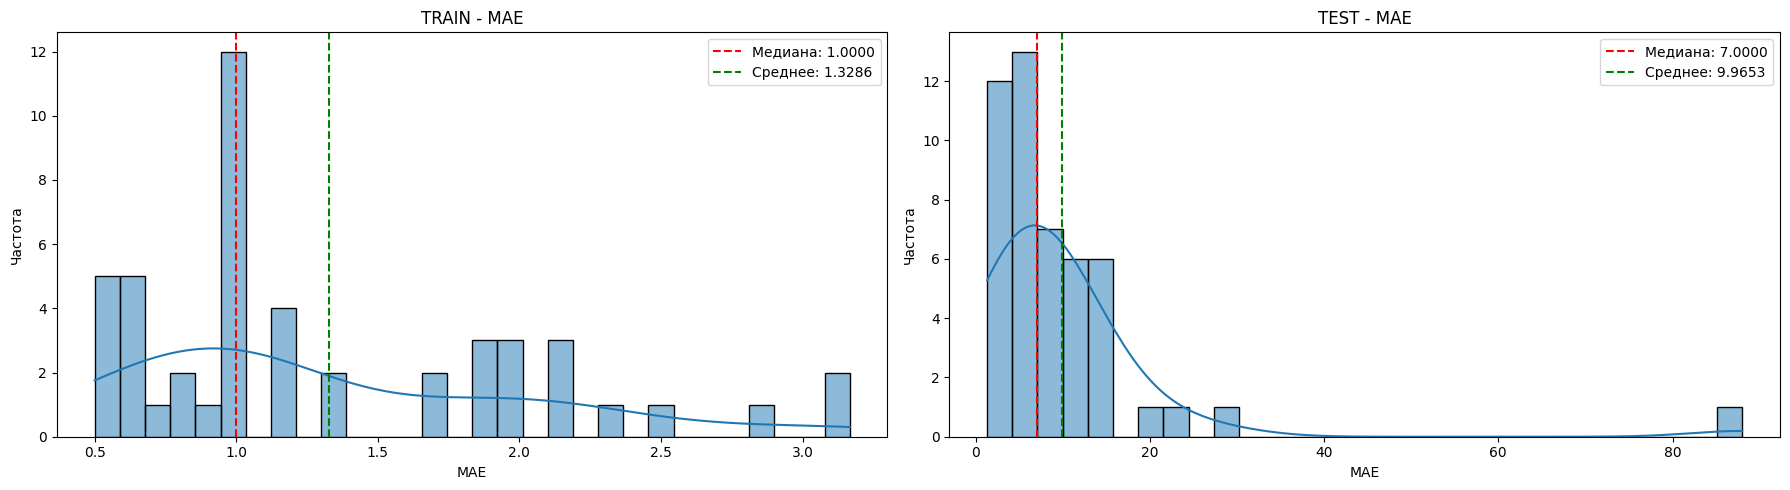

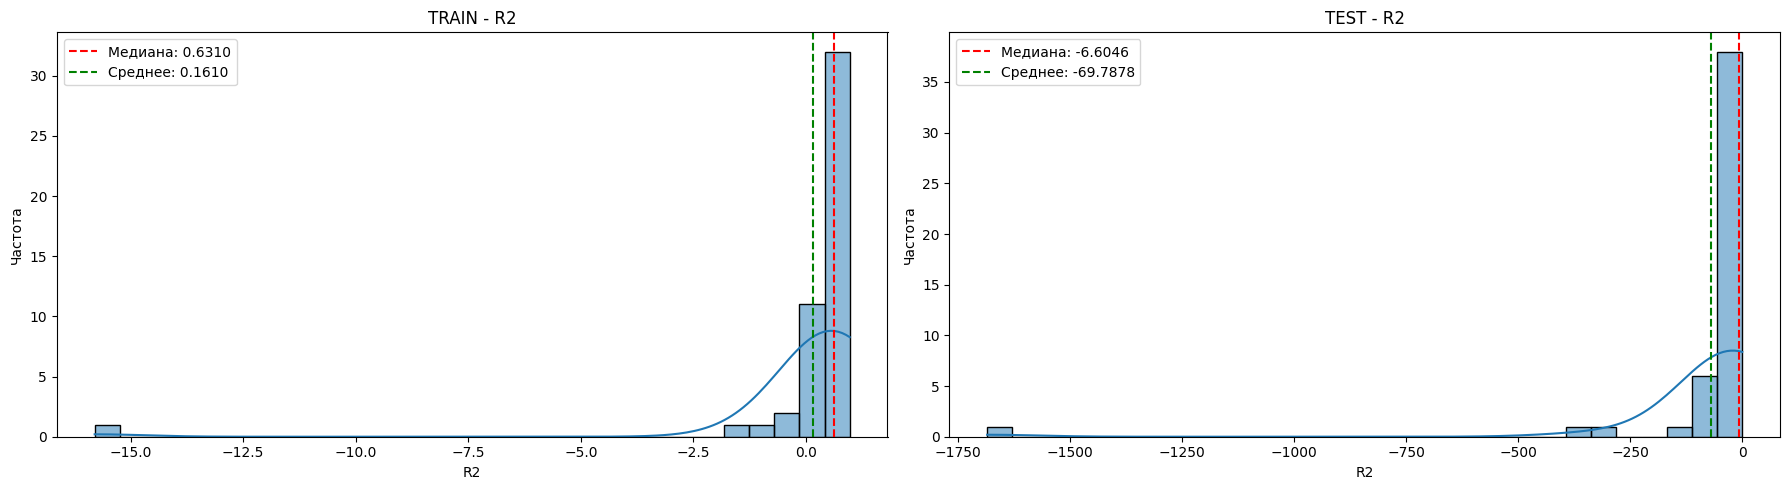

In [11]:
overall_df = results.get_overall_metrics_df()
panel_df = results.get_panel_metrics_df()


plot_overall_metrics_comparison(results)

plot_panel_metrics_distributions(
    results=results,
    metrics_to_plot=["mape", "rmse", "mae", "r2"],
)

In [12]:
plot_best_predictions(
    results=results,
    n_best=5,
    metric="rmse",
    split_name="test",
)

In [13]:
plot_worst_predictions(
    results=results,
    n_worst=5,
    metric="rmse",
    split_name="test",
)

In [14]:
feature_importance = catboost_model.get_feature_importance()
feature_names = regression_splits.train.drop(
    columns=[settings.columns.main_target, settings.columns.id, settings.columns.date]
).columns

importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": feature_importance,
    }
).sort_values("importance", ascending=False)

importance_df

,feature,importance
8,sales_pct_change_1,14.757495
9,panel_mean,12.204098
11,sales_vs_mean,11.784559
6,sales_ema_3,9.982819
5,sales_ema_2,9.477872
16,panel_id,9.107246
10,panel_std,6.881532
0,sales_lag_1,5.221077
7,sales_diff_1,4.998519
14,month_sin,3.967839
